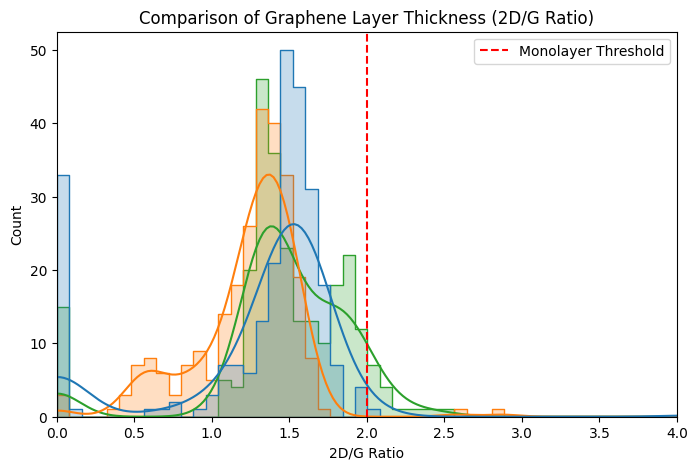

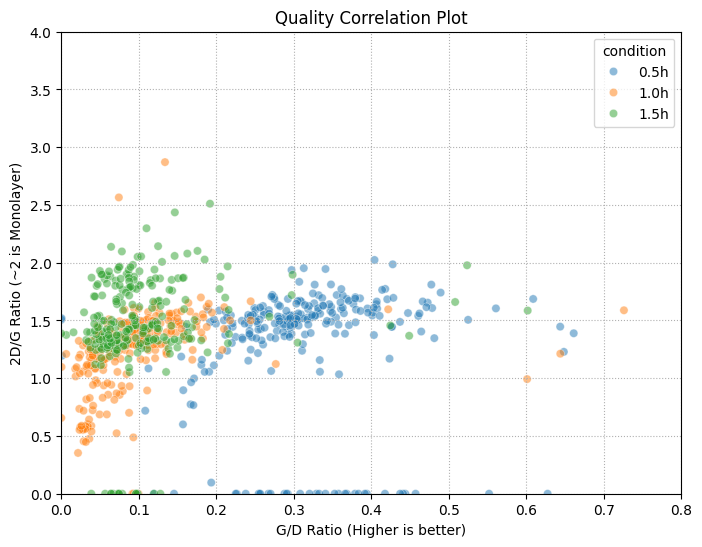

          2D_G_Ratio                     G_D_Ratio                    
                mean       std    median      mean       std    median
condition                                                             
0.5h        1.312428  0.605808  1.496221  0.366082  0.848346  0.304972
1.0h        1.233281  0.347220  1.303879  0.099016  0.081406  0.090089
1.5h        1.466455  0.459141  1.448168  0.178559  0.415153  0.088100


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df05 = pd.read_csv("output/spectra_mapping/S1/quantitative_results.csv")
df05['condition'] = '0.5h'
df10 = pd.read_csv("output/spectra_mapping/S2/quantitative_results.csv")
df10['condition'] = '1.0h'
df15 = pd.read_csv("output/spectra_mapping/S5/quantitative_results.csv")
df15['condition'] = '1.5h'

df_all = pd.concat([df05, df10, df15], ignore_index=True)

# 1. 2D/G比のヒストグラム比較
plt.figure(figsize=(8, 5))
sns.histplot(data=df_all, x="2D_G_Ratio", hue="condition", kde=True, element="step")
plt.axvline(2.0, color='red', linestyle='--', label='Monolayer Threshold')
plt.title("Comparison of Graphene Layer Thickness (2D/G Ratio)")
plt.xlabel("2D/G Ratio")
plt.xlim(0, 4)
plt.legend()
plt.show()

# 2. 2D/G vs G/D 相関散布図
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_all, x="G_D_Ratio", y="2D_G_Ratio", hue="condition", alpha=0.5)
plt.title("Quality Correlation Plot")
plt.xlabel("G/D Ratio (Higher is better)")
plt.ylabel("2D/G Ratio (~2 is Monolayer)")
plt.xlim(0, 0.8)
plt.ylim(0, 4)
plt.grid(True, linestyle=':')
plt.show()

# 3. 統計量の表示
stats = df_all.groupby('condition')[['2D_G_Ratio', 'G_D_Ratio']].agg(['mean', 'std', 'median'])
print(stats)